# Classifying PDF Documents Using Embedding and Machine Learning

## Objective

To develop a model capable of determining whether a PDF document is relevant or irrelevant to topics such as:

- Sistemas de pago.
- Gestión de riesgos.
- Inteligencia artificial.
- Protección de datos.
- Transformación digital.
- Ciberdefensa.

The model will use embedding to semantically represent the content of each document and machine learning algorithms to perform the classification.

## Expected Result

For each new PDF, the system will display:

- Classification: relevant or irrelevant.

- Label: 1 or 0.
- Probability of relevance.

- Closest topic, if the document is relevant.

- Thematic similarity.

In [1]:
# Instalation libreríes

!pip install -q pymupdf sentence-transformers joblib tqdm

In [2]:
# Conect Google Colab con Google Drive

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Libraries for file working and routes

In [3]:
import warnings
from pathlib import Path
import re
import hashlib

# Data processing
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# PDF reading
import fitz

# Progress bar
from tqdm.auto import tqdm

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

# Embeddings
from sentence_transformers import SentenceTransformer

# Model saving
import joblib

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Stage 1: Setting up the project in Google Colab

In this stage, the notebook is connected to the project folder stored in Google Drive, and the data, results, cache, and model paths are configured.

In [4]:
# Main project folder in Google Drive

RUTA_PROYECTO = Path(
    "/content/drive/MyDrive/Modelo_ML"
)

# Data folder

RUTA_DATA = RUTA_PROYECTO / "Data"
RUTA_RELEVANTES = RUTA_DATA / "relevantes"
RUTA_NO_RELEVANTES = RUTA_DATA / "no_relevantes"

# Output folder

RUTA_RESULTADOS = RUTA_PROYECTO / "resultados"
RUTA_MODELOS = RUTA_PROYECTO / "modelos"
RUTA_CACHE = RUTA_PROYECTO / "cache"

# # Create the entire structure if it doesn't already exist

rutas_proyecto = [
    RUTA_RELEVANTES,
    RUTA_NO_RELEVANTES,
    RUTA_RESULTADOS,
    RUTA_MODELOS,
    RUTA_CACHE
]

for ruta in rutas_proyecto:
    ruta.mkdir(parents=True, exist_ok=True)

print("Project structure prepared successfully.")
print("Main route:", RUTA_PROYECTO)

Project structure prepared successfully.
Main route: /content/drive/MyDrive/Modelo_ML


# Stage 2: Building the Document Inventory

The relevant and irrelevant document folders will be reviewed to create an inventory with the path, tag, and subject of each PDF.

#Function to Register PDFs

In [5]:
def obtener_documentos_pdf(ruta_base, etiqueta):
    """
    Registers the PDF files found in a folder
and all its subfolders.
    """

    documentos = []

    archivos_pdf = sorted(
        archivo
        for archivo in ruta_base.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() == ".pdf"
    )

    for ruta_pdf in archivos_pdf:

        if etiqueta == 1:
            tema = ruta_pdf.parent.name
            clasificacion = "Relevante"
        else:
            tema = "No relevante"
            clasificacion = "No relevante"

        documentos.append({
            "archivo": ruta_pdf.name,
            "ruta": str(ruta_pdf),
            "etiqueta": etiqueta,
            "clasificacion": clasificacion,
            "tema": tema
        })

    return documentos

# Create the complete inventory

In [6]:
def obtener_documentos_pdf(ruta_base, etiqueta):
    """
   Record the PDF files found in a folder and its subfolders
    """
    documentos = []

    archivos_pdf = sorted(
        archivo
        for archivo in ruta_base.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() == ".pdf"
    )

    for ruta_pdf in archivos_pdf:
        if etiqueta == 1:
            tema = ruta_pdf.parent.name
            clasificacion = "Relevante"
        else:
            tema = "No relevante"
            clasificacion = "No relevante"

        documentos.append({
            "archivo": ruta_pdf.name,
            "ruta": str(ruta_pdf),
            "etiqueta": etiqueta,
            "clasificacion": clasificacion,
            "tema": tema
        })

    return documentos

print("Function 'obtener_documentos_pdf'Defined and ready to use .")

Function 'obtener_documentos_pdf'Defined and ready to use .


In [7]:
#Ensure that the paths are defined
from pathlib import Path
import pandas as pd

RUTA_PROYECTO = Path("/content/drive/MyDrive/Modelo_ML")
RUTA_DATA = RUTA_PROYECTO / "Data"
RUTA_RELEVANTES = RUTA_DATA / "relevantes"
RUTA_NO_RELEVANTES = RUTA_DATA / "no_relevantes"

# Register both classes
documentos_relevantes = obtener_documentos_pdf(
    RUTA_RELEVANTES,
    etiqueta=1
)

documentos_no_relevantes = obtener_documentos_pdf(
    RUTA_NO_RELEVANTES,
    etiqueta=0
)

# Build the inventory
df_documentos = pd.DataFrame(
    documentos_relevantes
    + documentos_no_relevantes
)

if df_documentos.empty:
    print("Attention: No PDF files were found in the Drive folders.")
else:
    print("Project structure prepared correctly.")
    print("Total number of documents:", len(df_documentos))

    display(
        df_documentos["clasificacion"]
        .value_counts()
        .rename_axis("clase")
        .reset_index(name="cantidad")
    )

    display(df_documentos.head())

Project structure prepared correctly.
Total number of documents: 150


,clase,cantidad
0,Relevante,75
1,No relevante,75


,archivo,ruta,etiqueta,clasificacion,tema
0,Circular-002-2006-BCRP.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS
1,Circular-007-2007-BCRP.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS
2,Circular-017-2005-BCRP.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS
3,Circular-024-2001-BCRP.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS
4,circular-0002-2024-bcrp.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS


## Initial distribution of the documents

The number of documents available by class and by topic will be analyzed before starting the text extraction.

In [8]:
# Document count by topic

conteo_temas = (
    df_documentos["tema"]
    .value_counts()
    .rename_axis("tema")
    .reset_index(name="cantidad")
)

print("\nTopic distribution:")
display(conteo_temas)


Topic distribution:


,tema,cantidad
0,No relevante,75
1,BCRP SISTEMA DE PAGOS,22
2,SBS GESTION DE RIESGOS,21
3,PCM TRANSFORMACION DIGITAL,19
4,PCM IA,8
5,PCM PROTECCION DE DATOS,4
6,CIBERDEFENSA,1


# Chart by topic


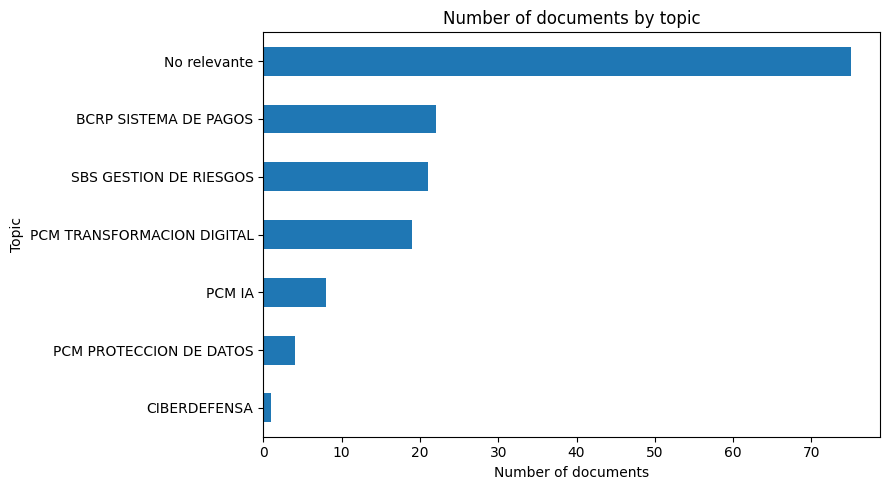

In [9]:
# Chart of number of documents by topic

conteo_temas_ordenado = (
    df_documentos["tema"]
    .value_counts()
    .sort_values(ascending=True)
)

conteo_temas_ordenado.plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Number of documents by topic")
plt.xlabel("Number of documents")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

## Saving the initial inventory

The inventory contains the name, path, tag, and subject of all the documents found.

In [10]:
# Save the initial inventory

ruta_inventario = (
    RUTA_RESULTADOS / "inventario_documentos.csv"
)

df_documentos.to_csv(
    ruta_inventario,
    index=False,
    encoding="utf-8-sig"
)

print("Inventory saved successfully in:")
print(ruta_inventario)

Inventory saved successfully in:
/content/drive/MyDrive/Modelo_ML/resultados/inventario_documentos.csv


# Stage 3: text extraction and validation

In this stage, the text content of all PDF documents will be extracted.

For each file, the following will be recorded:

- Number of pages.
- Number of characters.
- Number of words.
- Extraction status.
- Error message, when applicable.

Documents without extractable text or with insufficient content will be automatically identified and won't be used during training.

# Cleaning and extraction

In [11]:
def limpiar_texto(texto):
    """
    Perform a basic cleaning of the extracted text. Keep the semantic
    content and remove unnecessary spaces, tabs, and line breaks.
    """

    if not isinstance(texto, str):
        return ""

    texto = texto.replace("\x00", " ")
    texto = re.sub(r"\s+", " ", texto)
    texto = texto.strip()

    return texto


def extraer_informacion_pdf(ruta_pdf):
    """
    Extract the text and main features from a PDF.

    Returns
    -------
    dict
        Text, number of pages, words,  characters, extraction
        status, and  error message.
    """

    resultado = {
        "texto": "",
        "numero_paginas": 0,
        "cantidad_palabras": 0,
        "cantidad_caracteres": 0,
        "estado_extraccion": "Error",
        "mensaje_error": ""
    }

    documento = None

    try:
        ruta_pdf = Path(ruta_pdf)

        if not ruta_pdf.exists():
            raise FileNotFoundError(
                f"The file was not found: {ruta_pdf}"
            )

        documento = fitz.open(ruta_pdf)

        resultado["numero_paginas"] = documento.page_count

        textos_paginas = [
            pagina.get_text("text")
            for pagina in documento
        ]

        texto_completo = "\n".join(textos_paginas)
        texto_limpio = limpiar_texto(texto_completo)

        cantidad_palabras = len(texto_limpio.split())
        cantidad_caracteres = len(texto_limpio)

        resultado["texto"] = texto_limpio
        resultado["cantidad_palabras"] = cantidad_palabras
        resultado["cantidad_caracteres"] = cantidad_caracteres

        if cantidad_caracteres == 0:
            resultado["estado_extraccion"] = "Sin texto"

        elif cantidad_palabras < 50:
            resultado["estado_extraccion"] = "Texto insuficiente"

        else:
            resultado["estado_extraccion"] = "Correcto"

    except Exception as error:
        resultado["estado_extraccion"] = "Error"
        resultado["mensaje_error"] = str(error)

    finally:
        if documento is not None:
            documento.close()

    return resultado


print("Extraction functions created successfully.")

Extraction functions created successfully.


# Extract all the documents and combine the results

In [12]:
# Extract the text from all the documents

resultados_extraccion = []

print("Starting document extraction...\n")

for ruta_pdf in tqdm(
    df_documentos["ruta"],
    total=len(df_documentos),
    desc="Procesando PDF"
):
    resultados_extraccion.append(
        extraer_informacion_pdf(ruta_pdf)
    )

# Convert the results into a DataFrame

df_extraccion = pd.DataFrame(
    resultados_extraccion
)

# Combine inventory and extraction results

df_documentos = pd.concat(
    [
        df_documentos.reset_index(drop=True),
        df_extraccion.reset_index(drop=True)
    ],
    axis=1
)

print("\nExtraction finished.")
print("Processed documents:", len(df_documentos))

# Show a compact summary

resumen_extraccion = (
    df_documentos["estado_extraccion"]
    .value_counts(dropna=False)
    .rename_axis("estado")
    .reset_index(name="cantidad")
)

display(resumen_extraccion)

Starting document extraction...



Procesando PDF:   0%|          | 0/150 [00:00<?, ?it/s]


Extraction finished.
Processed documents: 150


,estado,cantidad
0,Correcto,136
1,Sin texto,14


# Summary by class

In [13]:
# Summary of extraction by class

resumen_clase_extraccion = (
    df_documentos
    .groupby(
        [
            "clasificacion",
            "estado_extraccion"
        ]
    )
    .size()
    .reset_index(name="cantidad")
)

display(resumen_clase_extraccion)

,clasificacion,estado_extraccion,cantidad
0,No relevante,Correcto,72
1,No relevante,Sin texto,3
2,Relevante,Correcto,64
3,Relevante,Sin texto,11


## Alternative recovery of documents without text

Some PDF files may display correctly, but not contain a text layer that can be extracted using PyMuPDF.

Before excluding these documents, a second recovery attempt will be made using the `pypdf` library.

This procedure will only be applied to documents whose initial status is:

- No text.
- Insufficient text.
- Extraction error.

Documents that also cannot be recovered using this second method will be excluded from the modeling set.

In [14]:
!pip install -q pypdf

In [15]:
# PDF extraction methods
import fitz
from pypdf import PdfReader

In [16]:
def extraer_texto_alternativo_pypdf(ruta_pdf):
    """
    Try to recover the textual content from a PDF using pypdf.

    This function is only used when the main extraction
    with PyMuPDF does not get enough text.

    Returns
    -------
    dict
        Recovered text, word count, characters,
        attempt status, and possible error message.

    """

    resultado = {
        "texto_alternativo": "",
        "palabras_alternativas": 0,
        "caracteres_alternativos": 0,
        "estado_alternativo": "Sin texto",
        "error_alternativo": ""
    }

    try:
        lector = PdfReader(str(ruta_pdf))
        textos_paginas = []

        for pagina in lector.pages:
            texto_pagina = pagina.extract_text() or ""
            textos_paginas.append(texto_pagina)

        texto_completo = " ".join(textos_paginas)
        texto_limpio = limpiar_texto(texto_completo)

        cantidad_palabras = len(texto_limpio.split())
        cantidad_caracteres = len(texto_limpio)

        resultado["texto_alternativo"] = texto_limpio
        resultado["palabras_alternativas"] = cantidad_palabras
        resultado["caracteres_alternativos"] = cantidad_caracteres

        if cantidad_caracteres == 0:
            resultado["estado_alternativo"] = "Sin texto"

        elif cantidad_palabras < 50:
            resultado["estado_alternativo"] = "Texto insuficiente"

        else:
            resultado["estado_alternativo"] = "Recuperado"

    except Exception as error:
        resultado["estado_alternativo"] = "Error"
        resultado["error_alternativo"] = str(error)

    return resultado


print("Alternative recovery function created successfully.")

Alternative recovery function created successfully.


# We try again to recover all the problematic documents



In [17]:
# Identify documents that need an alternative recovery

indices_problematicos = df_documentos[
    df_documentos["estado_extraccion"] != "Correcto"
].index

print(
    "Documents sent to the alternative method:",
    len(indices_problematicos)
)

resultados_alternativos = []

print("\nStarting alternative recovery with pypdf...\n")

for indice in tqdm(
    indices_problematicos,
    total=len(indices_problematicos),
    desc="Recuperación alternativa"
):
    ruta_pdf = df_documentos.loc[indice, "ruta"]

    resultado = extraer_texto_alternativo_pypdf(
        ruta_pdf
    )

    resultados_alternativos.append({
        "indice_original": indice,
        "archivo": df_documentos.loc[indice, "archivo"],
        **resultado
    })

df_recuperacion = pd.DataFrame(
    resultados_alternativos
)

print("\nSecond attempt finished.")

if not df_recuperacion.empty:
    display(
        df_recuperacion["estado_alternativo"]
        .value_counts(dropna=False)
        .rename_axis("resultado")
        .reset_index(name="cantidad")
    )
else:
    print("There were no documents that needed to be recovered.")

Documents sent to the alternative method: 14

Starting alternative recovery with pypdf...



Recuperación alternativa:   0%|          | 0/14 [00:00<?, ?it/s]


Second attempt finished.


,resultado,cantidad
0,Sin texto,14


## Creation of the set of valid documents

The second extraction method with `pypdf` also failed to retrieve textual content from the 14 problematic documents.

Therefore, these files will be temporarily excluded from the modeling set. They won't be physically deleted but will be kept as evidence of the validation process.

From this point on, work will only be done with documents that contain enough text to generate embeddings and train the classification models.

In [18]:
# Add the documents recovered with pypdf to the dataset

cantidad_recuperados = 0

if not df_recuperacion.empty:

    for _, fila in df_recuperacion.iterrows():

        if fila["estado_alternativo"] == "Recuperado":

            indice = int(fila["indice_original"])

            df_documentos.loc[
                indice,
                "texto"
            ] = fila["texto_alternativo"]

            df_documentos.loc[
                indice,
                "cantidad_palabras"
            ] = fila["palabras_alternativas"]

            df_documentos.loc[
                indice,
                "cantidad_caracteres"
            ] = fila["caracteres_alternativos"]

            df_documentos.loc[
                indice,
                "estado_extraccion"
            ] = "Correcto con pypdf"

            df_documentos.loc[
                indice,
                "mensaje_error"
            ] = ""

            cantidad_recuperados += 1

print(
    "Documents recovered using pypdf:",
    cantidad_recuperados
)

Documents recovered using pypdf: 0


# Create the valid set

In [19]:
# Accepted states for training

estados_validos = [
    "Correcto",
    "Correcto con pypdf"
]

# Documents that will actually be used in the modeling

df_modelado = (
    df_documentos[
        df_documentos["estado_extraccion"].isin(
            estados_validos
        )
    ]
    .reset_index(drop=True)
    .copy()
)

# Documents that are temporarily excluded

df_excluidos = (
    df_documentos[
        ~df_documentos["estado_extraccion"].isin(
            estados_validos
        )
    ]
    .reset_index(drop=True)
    .copy()
)

# Record the methodological decision

df_excluidos["decision_modelado"] = (
    "Excluido después de intentar extracción con PyMuPDF y pypdf"
)

print("Valid set created successfully.")
print("\nProcessing summary:")
print("- Original documents:", len(df_documentos))
print("- Recovered with pypdf:", cantidad_recuperados)
print("- Valid documents:", len(df_modelado))
print("- Excluded documents:", len(df_excluidos))

Valid set created successfully.

Processing summary:
- Original documents: 150
- Recovered with pypdf: 0
- Valid documents: 136
- Excluded documents: 14


# Show the final distribution by class and subject

In [20]:
# Final distribution of the valid documents

print("Distribution by class:")

display(
    df_modelado["clasificacion"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="cantidad")
)

print("\nDistribution by topic:")

display(
    df_modelado["tema"]
    .value_counts()
    .rename_axis("tema")
    .reset_index(name="cantidad")
)

Distribution by class:


,clase,cantidad
0,No relevante,72
1,Relevante,64



Distribution by topic:


,tema,cantidad
0,No relevante,72
1,BCRP SISTEMA DE PAGOS,22
2,SBS GESTION DE RIESGOS,21
3,PCM TRANSFORMACION DIGITAL,15
4,PCM PROTECCION DE DATOS,4
5,PCM IA,2


## Save the recovery evidence

In [21]:
# Save evidence of the second extraction method

ruta_recuperacion = (
    RUTA_RESULTADOS / "intento_recuperacion_pypdf.csv"
)

df_recuperacion.to_csv(
    ruta_recuperacion,
    index=False,
    encoding="utf-8-sig"
)

print("Recovery evidence saved in:")
print(ruta_recuperacion)

Recovery evidence saved in:
/content/drive/MyDrive/Modelo_ML/resultados/intento_recuperacion_pypdf.csv


# Save the excluded

In [22]:
# Save the excluded

ruta_excluidos = (
    RUTA_RESULTADOS / "documentos_excluidos.csv"
)

df_excluidos.to_csv(
    ruta_excluidos,
    index=False,
    encoding="utf-8-sig"
)

print("Excluded documents saved in:")
print(ruta_excluidos)

Excluded documents saved in:
/content/drive/MyDrive/Modelo_ML/resultados/documentos_excluidos.csv


# Save the valid dataset

In [23]:
# Save the valid set with the full text

ruta_dataset_valido = (
    RUTA_CACHE / "dataset_documentos_validos.pkl"
)

df_modelado.to_pickle(
    ruta_dataset_valido
)

print("Valid dataset saved in:")
print(ruta_dataset_valido)

Valid dataset saved in:
/content/drive/MyDrive/Modelo_ML/cache/dataset_documentos_validos.pkl


# Stage 4: detection and removal of duplicate documents

Documents with identical text content will be identified using a fingerprint or hash.

Duplicate files will not be physically deleted. Only one record of each content will be kept to prevent the model from learning repeated information.

In [24]:
def calcular_hash_texto(texto):
    """
    Generates a unique fingerprint from the textual content of each document.
    """

    texto_normalizado = re.sub(
        r"\s+",
        " ",
        str(texto).lower().strip()
    )

    return hashlib.sha256(
        texto_normalizado.encode("utf-8")
    ).hexdigest()


df_modelado["hash_texto"] = (
    df_modelado["texto"]
    .apply(calcular_hash_texto)
)

print("Hash generated successfully.")

Hash generated successfully.


## Quick check for duplicates

In [25]:
documentos_duplicados = df_modelado[
    df_modelado.duplicated(
        subset="hash_texto",
        keep=False
    )
].copy()

print(
    "Records involved in duplicates:",
    len(documentos_duplicados)
)

if not documentos_duplicados.empty:
    display(
        documentos_duplicados[
            [
                "archivo",
                "clasificacion",
                "tema",
                "cantidad_palabras",
                "hash_texto"
            ]
        ].sort_values("hash_texto")
    )
else:
    print("No duplicate documents were found.")

Records involved in duplicates: 4


,archivo,clasificacion,tema,cantidad_palabras,hash_texto
82,INFORME N 00035 - 2024 - GTI-PRI (1).pdf,No relevante,No relevante,2803,645beb3c1d59739928eadecb787a4ba19f984f303a047f...
83,INFORME N 00035 - 2024 - GTI-PRI.pdf,No relevante,No relevante,2803,645beb3c1d59739928eadecb787a4ba19f984f303a047f...
110,Osinergmin-Evaluacion-PAC-2025-I (1).pdf,No relevante,No relevante,7466,a5c69d8458ccc3150c104e9dbda763eb098067ba9d9c7d...
111,Osinergmin-Evaluacion-PAC-2025-I.pdf,No relevante,No relevante,7466,a5c69d8458ccc3150c104e9dbda763eb098067ba9d9c7d...


# Logically delete duplicates

In [26]:
df_modelado_limpio = (
    df_modelado
    .drop_duplicates(
        subset="hash_texto",
        keep="first"
    )
    .reset_index(drop=True)
    .copy()
)

print("Debugging completed.")
print("- Before:", len(df_modelado))
print("- After:", len(df_modelado_limpio))
print(
    "- Duplicates removed:",
    len(df_modelado) - len(df_modelado_limpio)
)

Debugging completed.
- Before: 136
- After: 134
- Duplicates removed: 2


# Save results and obtain the clean dataset

In [27]:
# Save duplicate evidence

ruta_duplicados = (
    RUTA_RESULTADOS / "documentos_duplicados.csv"
)

documentos_duplicados.to_csv(
    ruta_duplicados,
    index=False,
    encoding="utf-8-sig"
)

# Save clean dataset

ruta_dataset_limpio = (
    RUTA_CACHE / "dataset_modelado_limpio.pkl"
)

df_modelado_limpio.to_pickle(
    ruta_dataset_limpio
)

print("Results saved successfully.")
print("Duplicates:", ruta_duplicados)
print("Clean dataset:", ruta_dataset_limpio)

Results saved successfully.
Duplicates: /content/drive/MyDrive/Modelo_ML/resultados/documentos_duplicados.csv
Clean dataset: /content/drive/MyDrive/Modelo_ML/cache/dataset_modelado_limpio.pkl


#  Stage 5: splitting the training and test set

The clean set will be divided into:

- 80% for training.
- 20% for testing.

The split will be stratified to keep the proportion of relevant and non-relevant documents in both sets.

In [28]:
df_train, df_test = train_test_split(
    df_modelado_limpio,
    test_size=0.20,
    random_state=42,
    stratify=df_modelado_limpio["etiqueta"]
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Division completed.")
print("- Training:", len(df_train))
print("- Test:", len(df_test))

Division completed.
- Training: 107
- Test: 27


## Save the division

In [29]:
ruta_train = RUTA_CACHE / "documentos_train.pkl"
ruta_test = RUTA_CACHE / "documentos_test.pkl"

df_train.to_pickle(ruta_train)
df_test.to_pickle(ruta_test)

print("Sets saved correctly.")
print("Train:", ruta_train)
print("Test:", ruta_test)

Sets saved correctly.
Train: /content/drive/MyDrive/Modelo_ML/cache/documentos_train.pkl
Test: /content/drive/MyDrive/Modelo_ML/cache/documentos_test.pkl


# Stage 6: text fragmentation

Each document will be split into chunks of about 350 words with a 50-word overlap.

The overlap helps keep the context between consecutive chunks.

### Fragmentation function

In [30]:
def dividir_texto_en_fragmentos(
    texto,
    tamano_fragmento=350,
    solapamiento=50
):
    """
    Divide a text into word fragments with overlap.
    """

    if not isinstance(texto, str) or not texto.strip():
        return []

    if solapamiento >= tamano_fragmento:
        raise ValueError(
            "The overlap must be smaller than the fragment size."
        )

    palabras = texto.split()
    fragmentos = []

    paso = tamano_fragmento - solapamiento

    for inicio in range(0, len(palabras), paso):
        fin = inicio + tamano_fragmento

        fragmento = " ".join(
            palabras[inicio:fin]
        ).strip()

        if fragmento:
            fragmentos.append(fragmento)

    return fragmentos

## Split train and test

In [31]:
df_train["fragmentos"] = df_train["texto"].apply(
    dividir_texto_en_fragmentos
)

df_test["fragmentos"] = df_test["texto"].apply(
    dividir_texto_en_fragmentos
)

df_train["cantidad_fragmentos"] = (
    df_train["fragmentos"].apply(len)
)

df_test["cantidad_fragmentos"] = (
    df_test["fragmentos"].apply(len)
)

print("Fragmentation completed.")
print(
    "Training fragments:",
    df_train["cantidad_fragmentos"].sum()
)
print(
    "Test fragments:",
    df_test["cantidad_fragmentos"].sum()
)

print(
    "Documents without fragments:",
    (
        (df_train["cantidad_fragmentos"] == 0).sum()
        + (df_test["cantidad_fragmentos"] == 0).sum()
    )
)

Fragmentation completed.
Training fragments: 1994
Test fragments: 791
Documents without fragments: 0


## Save fragmented documents

In [32]:
ruta_train_fragmentado = (
    RUTA_CACHE / "documentos_train_fragmentados.pkl"
)

ruta_test_fragmentado = (
    RUTA_CACHE / "documentos_test_fragmentados.pkl"
)

df_train.to_pickle(ruta_train_fragmentado)
df_test.to_pickle(ruta_test_fragmentado)

print("Fragmented sets saved correctly.")

Fragmented sets saved correctly.


# Stage 7: Embedding generation

Each fragment will be transformed into a numerical vector using a multilingual Sentence Transformers model.

Then, the average of the embeddings of all the fragments of each PDF will be calculated to get a single representation per document.

## Load the model

In [33]:
NOMBRE_MODELO_EMBEDDINGS = (
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

print("Loading embeddings model...")

modelo_embeddings = SentenceTransformer(
    NOMBRE_MODELO_EMBEDDINGS
)

print("Model loaded correctly.")
print(
    "Embedding dimension:",
    modelo_embeddings.get_sentence_embedding_dimension()
)

Loading embeddings model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded correctly.
Embedding dimension: 384


## Create the embedding function per document

In [34]:
def generar_embedding_documento(
    fragmentos,
    modelo,
    batch_size=16
):
    """
    Generate a single embedding for an entire document.

    First, get the embedding for each fragment and then
    calculate the average of all the vectors.
    """

    if not isinstance(fragmentos, list) or len(fragmentos) == 0:
        raise ValueError(
            "The document doesn't contain any valid fragments."
        )

    embeddings_fragmentos = modelo.encode(
        fragmentos,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    embedding_documento = embeddings_fragmentos.mean(axis=0)

    norma = np.linalg.norm(embedding_documento)

    if norma > 0:
        embedding_documento = (
            embedding_documento / norma
        )

    return embedding_documento.astype(np.float32)

## Generate training embeddings

In [35]:
embeddings_train = []

print("Generating training embeddings...\n")

for fragmentos in tqdm(
    df_train["fragmentos"],
    total=len(df_train),
    desc="Embeddings train"
):
    embedding = generar_embedding_documento(
        fragmentos=fragmentos,
        modelo=modelo_embeddings,
        batch_size=16
    )

    embeddings_train.append(embedding)

print("Training embeddings completed.")

Generating training embeddings...



Embeddings train:   0%|          | 0/107 [00:00<?, ?it/s]

Training embeddings completed.


## Generate test embeddings

In [36]:
embeddings_test = []

print("Generating test embeddings...\n")

for fragmentos in tqdm(
    df_test["fragmentos"],
    total=len(df_test),
    desc="Embeddings test"
):
    embedding = generar_embedding_documento(
        fragmentos=fragmentos,
        modelo=modelo_embeddings,
        batch_size=16
    )

    embeddings_test.append(embedding)

print("Test embeddings completed.")

Generating test embeddings...



Embeddings test:   0%|          | 0/27 [00:00<?, ?it/s]

Test embeddings completed.


## Create the matrices

In [37]:
X_train = np.vstack(embeddings_train)
X_test = np.vstack(embeddings_test)

y_train = df_train["etiqueta"].to_numpy()
y_test = df_test["etiqueta"].to_numpy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (107, 384)
X_test: (27, 384)
y_train: (107,)
y_test: (27,)


## Save embeddings

In [38]:
np.save(
    RUTA_CACHE / "X_train_embeddings.npy",
    X_train
)

np.save(
    RUTA_CACHE / "X_test_embeddings.npy",
    X_test
)

np.save(
    RUTA_CACHE / "y_train.npy",
    y_train
)

np.save(
    RUTA_CACHE / "y_test.npy",
    y_test
)

df_train["embedding"] = list(X_train)
df_test["embedding"] = list(X_test)

df_train.to_pickle(
    RUTA_CACHE / "documentos_train_con_embeddings.pkl"
)

df_test.to_pickle(
    RUTA_CACHE / "documentos_test_con_embeddings.pkl"
)

print("Embeddings saved correctly.")

Embeddings saved correctly.


# Stage 8: training classification models

The document embeddings will be used to train three models:

- Logistic regression.
- Linear SVM.
- Random Forest.

The target variable is:

- 0: not relevant document.
- 1: relevant document.

## Create the models

In [39]:
modelos = {
    "Regresión logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "SVM lineal": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print("Models created correctly.")

Models created correctly.


## Train the models

In [40]:
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando: {nombre}")

    modelo.fit(X_train, y_train)

    modelos_entrenados[nombre] = modelo

print("\nAll the models were trained.")

Entrenando: Regresión logística
Entrenando: SVM lineal
Entrenando: Random Forest

All the models were trained.


# Stage 9: evaluation and comparison

The models will be tested with documents that weren't used in training.

The following metrics will be used:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC-AUC.

## Evaluation function

In [41]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    """
    Evaluate a binary classification model.
    """

    predicciones = modelo.predict(X_test)
    probabilidades = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, predicciones),
        "precision": precision_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilidades
        )
    }

    return metricas, predicciones, probabilidades

## Evaluate all the models

In [42]:
resultados_modelos = {}
lista_metricas = []

for nombre, modelo in modelos_entrenados.items():

    metricas, predicciones, probabilidades = evaluar_modelo(
        nombre,
        modelo,
        X_test,
        y_test
    )

    lista_metricas.append(metricas)

    resultados_modelos[nombre] = {
        "predicciones": predicciones,
        "probabilidades": probabilidades
    }

df_metricas = pd.DataFrame(lista_metricas)

df_metricas = df_metricas.sort_values(
    by=["f1_score", "recall", "roc_auc"],
    ascending=False
).reset_index(drop=True)

display(df_metricas.round(4))

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,SVM lineal,1.0000,1.0000,1.0000,1.0000,1.000
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.000
2,Regresión logística,0.9259,0.9231,0.9231,0.9231,0.989


## Comparative metrics chart

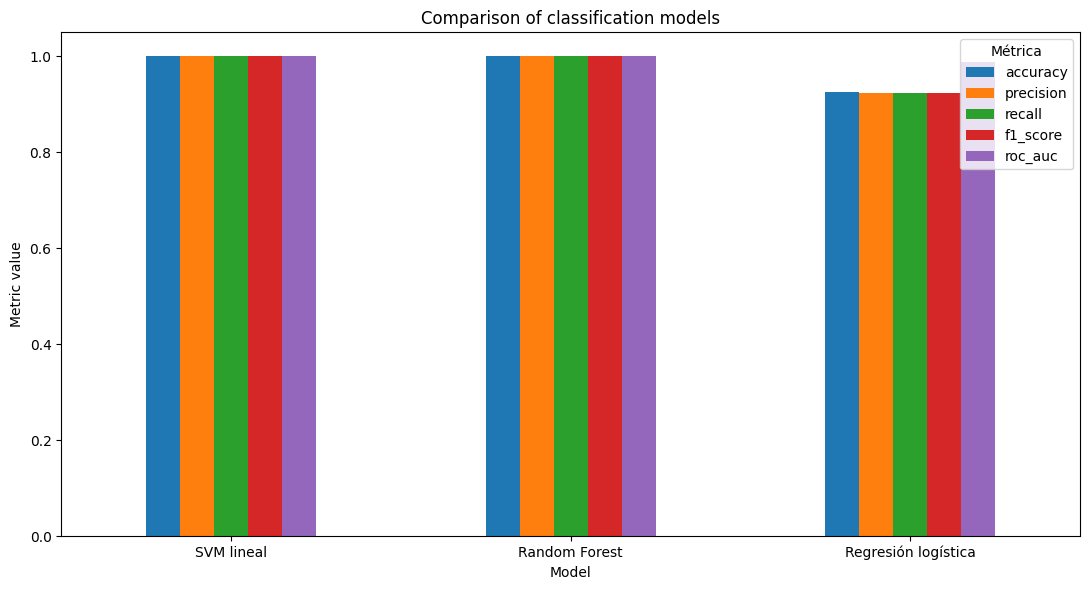

In [43]:
metricas_grafico = (
    df_metricas
    .set_index("modelo")[
        [
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc"
        ]
    ]
)

metricas_grafico.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of classification models")
plt.xlabel("Model")
plt.ylabel("Metric value")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

# Stage 10: Classification of a New PDF Document

The model with the best F1-score, recall, and ROC-AUC will be selected.

Afterwards, a new PDF document that hasn't been part of the training or testing will be loaded. The document will be processed following exactly the same flow used during training:

1. Text extraction.
2. Cleaning.
3. Fragmentation.
4. Embedding generation.
5. Model prediction.
6. Relevance probability calculation.

In [44]:
# Automatically select the model with the best metrics
mejor_nombre_modelo = df_metricas.loc[0, "modelo"]
mejor_modelo = modelos_entrenados[
    mejor_nombre_modelo
]

print("Best model selected:")
print(mejor_nombre_modelo)


Best model selected:
SVM lineal


## Save the best model

In [45]:
# Save the best model on Google Drive

ruta_mejor_modelo = (
    RUTA_MODELOS / "mejor_modelo_clasificacion.joblib"
)

joblib.dump(
    mejor_modelo,
    ruta_mejor_modelo
)

print("Best model saved correctly in:")
print(ruta_mejor_modelo)

Best model saved correctly in:
/content/drive/MyDrive/Modelo_ML/modelos/mejor_modelo_clasificacion.joblib


## Function to sort a new PDF

In [46]:
def clasificar_pdf_nuevo(
    ruta_pdf,
    modelo_clasificacion,
    modelo_embeddings,
    umbral=0.50
):
    """
    Classify a new PDF document as relevant or not relevant.

    Parameters
    ----------
    ruta_pdf : str o Path
        Path of the PDF you want to classify.

    modelo_clasificacion
        Pre-trained Machine Learning model.

    modelo_embeddings : SentenceTransformer
        SentenceTransformer Model used to generate the embeddings.

    umbral : float
        Minimum probability to classify the document as relevant.

    Returns
    -------
    dict
        Result of the classification and document features.
    """

    ruta_pdf = Path(ruta_pdf)

    # 1. Extract information from the PDF
    informacion = extraer_informacion_pdf(ruta_pdf)

    if informacion["estado_extraccion"] != "Correcto":
        return {
            "documento": ruta_pdf.name,
            "estado": informacion["estado_extraccion"],
            "mensaje": (
                "It wasn’t possible to get enough text to classify the document"
            )
        }

    # 2. Split the text into pieces
    fragmentos = dividir_texto_en_fragmentos(
        informacion["texto"],
        tamano_fragmento=350,
        solapamiento=50
    )

    if len(fragmentos) == 0:
        return {
            "documento": ruta_pdf.name,
            "estado": "Sin fragmentos",
            "mensaje": (
                "The document didn't generate any valid fragments."
            )
        }

    # 3. Generate the document embedding
    embedding = generar_embedding_documento(
        fragmentos=fragmentos,
        modelo=modelo_embeddings,
        batch_size=16
    )

    # Convert to a single-row array
    X_nuevo = embedding.reshape(1, -1)

    # 4. Obtener probabilidad de relevancia
    probabilidad_relevancia = (
        modelo_clasificacion.predict_proba(X_nuevo)[0, 1]
    )

    # 5. Apply the threshold
    etiqueta_predicha = int(
        probabilidad_relevancia >= umbral
    )

    clasificacion = (
        "Relevante"
        if etiqueta_predicha == 1
        else "No relevante"
    )

    return {
        "document": ruta_pdf.name,
        "status": "Procesado correctamente",
        "classification": clasificacion,
        "label": etiqueta_predicha,
        "relevance_probability": probabilidad_relevancia,
        "number_of_pages": informacion["numero_paginas"],
        "word_count": informacion["cantidad_palabras"],
        "number_of_fragments": len(fragmentos)
    }


print("Classification function created successfully.")

Classification function created successfully.


## Upload the PDF, validate the file, and get its path

In [47]:
from google.colab import files

print("Select a PDF document to classify.")

archivos_subidos = files.upload()

# Get the name of the uploaded file

if len(archivos_subidos) == 0:
    raise ValueError(
        "No file was selected."
    )

nombre_pdf_nuevo = next(
    iter(archivos_subidos.keys())
)

ruta_pdf_nuevo = Path(
    "/content"
) / nombre_pdf_nuevo

if ruta_pdf_nuevo.suffix.lower() != ".pdf":
    raise ValueError(
        "The selected file doesn't have a PDF extension."
    )

print("Document successfully uploaded:")
print(ruta_pdf_nuevo)

Select a PDF document to classify.


Saving 02-informe-tecnico-produccion-nacional-diciembre-2025.pdf to 02-informe-tecnico-produccion-nacional-diciembre-2025.pdf
Document successfully uploaded:
/content/02-informe-tecnico-produccion-nacional-diciembre-2025.pdf


## Predict the new PDF

In [48]:
resultado_pdf_nuevo = clasificar_pdf_nuevo(
    ruta_pdf=ruta_pdf_nuevo,
    modelo_clasificacion=mejor_modelo,
    modelo_embeddings=modelo_embeddings,
    umbral=0.50
)

resultado_pdf_nuevo

{'document': '02-informe-tecnico-produccion-nacional-diciembre-2025.pdf',
 'status': 'Procesado correctamente',
 'classification': 'No relevante',
 'label': 0,
 'relevance_probability': np.float64(0.008669396152696884),
 'number_of_pages': 70,
 'word_count': 33445,
 'number_of_fragments': 112}